# 00 — Start here

**Seeing Through Solid Rock: Finding a Hidden Chamber with Cosmic-Ray Muons**

Welcome. Over the next eight weeks you are going to build a simulation from a supplied starter codebase of one of the strangest measurements in physics: looking inside a
solid mountain by counting particles that fall out of the sky.

### What you are aiming at

By week 8 you will be able to answer this question with a number:

> Under the simulation model, **how many days would the baseline detector need
> before the expected chamber signal reaches 5σ?**

Nobody is going to tell you the answer. You are going to compute it.

### How the notebooks work

Each notebook mixes three kinds of cell:

- **Explanation** — read it, don't skim it.
- **Given code** — already written, just run it.
- **`# YOUR TURN`** — you write this. This is the actual project.

Where a cell says *check yourself*, there is a number you should be able to
reproduce. If you can't, that is not a failure — it is the most useful thing
that can happen in a week, and it is exactly what your weekly update is for.

### One rule

Commit your work to git at the end of every session, even when it is broken.
`git commit -m "opacity loop still wrong, opacity comes out negative"` is a
perfectly respectable commit message and a far better record of research than
a tidy repository that appears from nowhere in week 8.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../code'))
import numpy as np
import matplotlib.pyplot as plt
import muography as mg
import project_config as cfg
print('ready — MYSSP Project P-1')


ready — MYSSP Project P-1


## Does everything work?

Run the cell below. If you see a plot of a curve falling steeply to the right,
you are set up correctly.

The notebooks are designed to be independent. Later notebooks import the shared functions from `code/student_analysis.py`; they do not depend on variables left in memory by an earlier notebook.


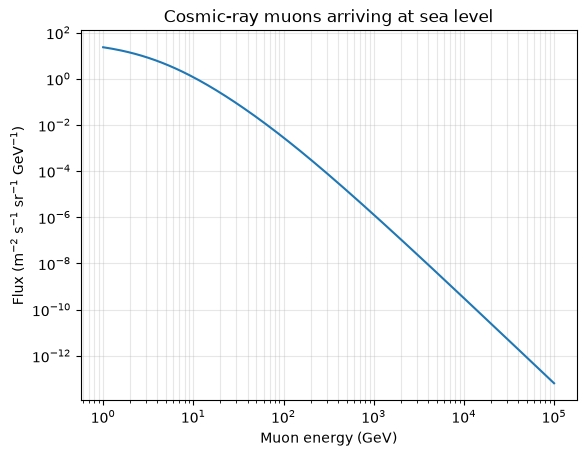

In [4]:
E = np.logspace(0, 5, 200)          # muon energies from 1 to 100,000 GeV
flux = mg.gaisser_flux(E, theta=0.0)

plt.loglog(E, flux)
plt.xlabel('Muon energy (GeV)')
plt.ylabel('Flux (m$^{-2}$ s$^{-1}$ sr$^{-1}$ GeV$^{-1}$)')
plt.title('Cosmic-ray muons arriving at sea level')
plt.grid(alpha=0.3, which='both')
plt.savefig('../figures/00_spectrum.png', dpi=300, bbox_inches='tight')
plt.show()

## Python warm-up

If you have not used numpy before, spend your first session here. Everything in
this project is built from four ideas, and no more than four.

**1. An array is many numbers at once.**

In [6]:
x = np.array([1.0, 2.0, 3.0, 4.0])
print(x * 10)        # every element, at once -- no loop needed -- element-wise multiply
print(x ** 2) # element-wise square
print(x.sum(), x.mean(), x.max()) # sum, mean, max

[10. 20. 30. 40.]
[ 1.  4.  9. 16.]
10.0 2.5 4.0


**2. Making arrays without typing them out.**

In [7]:
print(np.arange(0, 2.0, 0.5)) 
print(np.arange(0, 10, 2)) # start, stop, step
print(np.linspace(0, 1, 5))          # start, stop, how many
print(np.logspace(0, 3, 4))          # 10^0 to 10^3, evenly in log

[0.  0.5 1.  1.5]
[0 2 4 6 8]
[0.   0.25 0.5  0.75 1.  ]
[   1.   10.  100. 1000.]


**3. Choosing elements with a condition.**

In [9]:
v = np.array([3.0, 9.0, 1.0, 7.0])
print(v > 5)                 # a mask of True/False
print(v[v > 5])              # only the big ones
print(np.where(v > 5, 0.0, v))   # replace the big ones with zero
v = np.array([1, 6, 3, 8, 2])
print(v > 5)           # [False, True, False, True, False]
print(v[v > 5])        # [6, 8]
print(np.where(v > 5)) # (array([1, 3]),)

[False  True False  True]
[9. 7.]
[3. 0. 1. 0.]
[False  True False  True False]
[6 8]
(array([1, 3]),)


**4. A grid of two variables.**

This one takes a moment to get used to, and you will use it constantly.

In [10]:
a = np.array([0.0, 1.0, 2.0])
A, B = np.meshgrid(a, a, indexing='xy')
print('A =\n', A)
print('B =\n', B)
print('A + B =\n', A + B)
x = np.linspace(-1, 1, 3)
y = np.linspace(-1, 1, 3)
X, Y = np.meshgrid(x, y, indexing='xy')
print(X)
print(Y)

A =
 [[0. 1. 2.]
 [0. 1. 2.]
 [0. 1. 2.]]
B =
 [[0. 0. 0.]
 [1. 1. 1.]
 [2. 2. 2.]]
A + B =
 [[0. 1. 2.]
 [1. 2. 3.]
 [2. 3. 4.]]
[[-1.  0.  1.]
 [-1.  0.  1.]
 [-1.  0.  1.]]
[[-1. -1. -1.]
 [ 0.  0.  0.]
 [ 1.  1.  1.]]


### YOUR TURN

Write a few lines that create 1000 energies between 1 and 10,000 GeV, compute
the flux at each, and print how many of them have a flux below 1e-6.

There is no trick here. It is just to make sure the four ideas above are yours
before you need them.

In [11]:
# YOUR TURN
E = np.linspace(1, 10000, 1000)
flux = mg.gaisser_flux(E, theta=0.0)
n_below = np.sum(flux < 1e-6)
print(n_below)

892


In [12]:
print(mg.gaisser_flux.__doc__)


    Differential muon flux at sea level.

    How many muons arrive per m^2, per second, per steradian, per GeV of
    energy, at energy E and zenith angle theta.

    Parameters
    ----------
    E : float or array
        Muon energy in GeV.
    theta : float or array
        Zenith angle in radians. theta = 0 is straight overhead.

    Returns
    -------
    dI/dE in  muons m^-2 s^-1 sr^-1 GeV^-1

    Notes
    -----
    This is a standard formula from the Particle Data Group, with the
    low-energy correction of Guan et al. (2015). It is a fit to measurements,
    not something derived from first principles. Without the correction the
    original formula badly over-predicts below about 10 GeV; with it, the
    whole range is usable. For us the high-energy end matters most anyway,
    because a muon needs tens of GeV just to get through rock.
    


### Before you close this notebook

Open `docs/primer.md` and read sections 1 and 2. It is written for exactly
where you are now, and the next notebook assumes it.

In [13]:
mg.minimum_energy(25000)

np.float64(52.58545903782386)